In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/preapuntes IA/Mi repositorio/Laboratorios/Lab2/KaggleV2-May-2016.csv')

# **LABORATORIO 02 - Predicción de Faltas a Citas Médicas mediante Modelos de Regresión**

1. Introducción y Contexto del Dataset

1.1. Descripción del Problema

  El dataset "Medical Appointment No-Shows" contiene registros de más de 110,000 citas médicas en Brasil, con el objetivo principal de predecir si un paciente faltará a su cita programada. Este problema representa un desafío significativo para los sistemas de salud, ya que las faltas implican:

    Pérdida de recursos económicos y tiempo médico especializado

    Aumento en listas de espera para otros pacientes

    Interrupción en tratamientos continuos y seguimiento de pacientes crónicos

    Ineficiencia en la planificación de recursos clínicos

1.2. Variables Principales

El conjunto de datos incluye 14 variables predictoras que capturan información demográfica, socioeconómica y logística:

    Variables demográficas: Edad (Age), Género (Gender)

    Variables de salud: Hipertensión, Diabetes, Alcoholismo, Discapacidad

    Variables socioeconómicas: Beca Bolsa Familia (Scholarship), Barrio (Neighbourhood)

    Variables logísticas: Días de espera (Waiting_Days), Recepción de SMS recordatorio

    Variable objetivo: No_show_numeric (transformada para regresión)

1.3. Justificación para Regresión Lineal Multivariable

¿Por qué es viable y apropiado usar regresión lineal multivariable?

Naturaleza del Target Transformado:

    Transformé la variable categórica original (No-show)
    en una variable numérica continua (No_show_numeric)

Esta nueva variable representa la probabilidad de falta (valores entre 0 y 1)

    La regresión lineal es ideal para modelar relaciones
    entre múltiples predictores y una variable objetivo
    continua



**Relaciones Lineales Identificables:**

Mi análisis exploratorio revela relaciones lineales significativas:

    Días de espera ↔ Probabilidad de falta: Correlación positiva

    Edad ↔ Probabilidad de falta: Correlación negativa

    SMS recibido ↔ Probabilidad de falta: Correlación positiva

Estas relaciones pueden ser capturadas efectivamente por coeficientes lineales

**Múltiples Predictores Interrelacionados:**

El fenómeno de las faltas médicas está influenciado por múltiples factores simultáneamente

La regresión multivariable me permite cuantificar el impacto individual de cada variable mientras controlo por las demás

Ejemplo: Puedo medir el efecto de la edad sobre la probabilidad de falta, manteniendo constantes los días de espera y el barrio

**Interpretabilidad de Resultados:**

Los coeficientes del modelo me proporcionan insights accionables:

    "Por cada día adicional de espera, la probabilidad de falta aumenta en X%"

    "Los pacientes del barrio Y tienen Z% más probabilidad de faltar que aquellos del barrio Z"

**Base para Modelos Más Complejos:**

La regresión lineal me sirve como línea base para comparar con modelos más sofisticados

Me permite validar si relaciones no lineales (capturadas por regresión polinómica) mejoran significativamente la predicción

# **Hipótesis Principal: Existe una combinación lineal de factores demográficos, socioeconómicos y logísticos que puede predecir significativamente la probabilidad de que un paciente falle a su cita médica.**

In [2]:
#1
print("Dimensiones del dataset original:", df.shape)
print("\nPrimeras 5 filas del dataset:")
df.head()

Dimensiones del dataset original: (110527, 14)

Primeras 5 filas del dataset:


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
# 2. Análisis Exploratorio y Preprocesamiento
print("Dimensiones del dataset original:", df.shape)
print("\nInformación del dataset:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

# Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Análisis de la variable objetivo
print("\nDistribución de la variable objetivo (No-show):")
print(df['No-show'].value_counts())
print("\nProporciones:")
print(df['No-show'].value_counts(normalize=True))

# Crear la variable objetivo numérica para regresión
df['No_show_numeric'] = (df['No-show'] == 'Yes').astype(int)



Dimensiones del dataset original: (110527, 14)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB
None

Estadística

Hallazgos iniciales:

Dataset completo sin valores nulos

Variables temporales en formato objeto requieren transformación

Presencia de outliers en edad (-1, 115+) que distorsionarían el modelo

Variable Handcap con valores inconsistentes con su descripción teórica

# Preprocesamiento y Transformación de **Datos**

Transformaciones Aplicadas
Las operaciones de preprocesamiento se basan en los principios de consistencia matemática y relevancia predictiva:

Normalización de variables temporales para calcular el feature Waiting_Days

Eliminación de identificadores únicos (PatientId, AppointmentID) por carecer de valor predictivo

Filtrado de outliers en edad para mantener consistencia biológica

Codificación de variables categóricas según la teoría de representación numérica

Binarización de variables para alinear su comportamiento con la descripción teórica

Justificación matemática: Estas transformaciones aseguran que la matriz de características cumpla con los supuestos de invertibilidad y continuidad requeridos por los algoritmos de regresión lineal.

In [4]:
# 2. ANÁLISIS EXPLORATORIO Y PREPROCESAMIENTO

print("=" * 60)
print("2. ANÁLISIS EXPLORATORIO Y PREPROCESAMIENTO")
print("=" * 60)

# 2.1. Análisis inicial del dataset
print("Dimensiones del dataset original:", df.shape)
print("\nInformación del dataset:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

# 2.2. Verificación de calidad de datos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# 2.3. Análisis de la variable objetivo
print("\nDistribución de la variable objetivo (No-show):")
print(df['No-show'].value_counts())
print("\nProporciones:")
print(df['No-show'].value_counts(normalize=True))

# 2.4. Creación de variable objetivo numérica
df['No_show_numeric'] = (df['No-show'] == 'Yes').astype(int)
print(f"\nVariable objetivo numérica creada: No_show_numeric")
print(f"Distribución: {df['No_show_numeric'].value_counts().to_dict()}")

# 2.5. Identificación de problemas de datos
print("\n" + "-" * 40)
print("IDENTIFICACIÓN DE PROBLEMAS EN LOS DATOS")
print("-" * 40)

# Edades problemáticas
print(f"Edad mínima: {df['Age'].min()}")
print(f"Edad máxima: {df['Age'].max()}")
print(f"Registros con edad < 0: {(df['Age'] < 0).sum()}")
print(f"Registros con edad > 100: {(df['Age'] > 100).sum()}")

# Variables Handcap (debería ser binaria según descripción)
print(f"\nValores únicos en Handcap: {sorted(df['Handcap'].unique())}")
print("Distribución de Handcap:")
print(df['Handcap'].value_counts().sort_index())

# 2.6. Análisis de relaciones preliminares
print("\n" + "-" * 40)
print("ANÁLISIS DE RELACIONES PRELIMINARES")
print("-" * 40)

# Relación básica entre variables numéricas y target
numeric_vars = ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received']
print("Correlación con variable objetivo:")
for var in numeric_vars:
    correlation = df[var].corr(df['No_show_numeric'])
    print(f"{var}: {correlation:.4f}")

print("\nAnálisis completado. ")

2. ANÁLISIS EXPLORATORIO Y PREPROCESAMIENTO
Dimensiones del dataset original: (110527, 15)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   PatientId        110527 non-null  float64
 1   AppointmentID    110527 non-null  int64  
 2   Gender           110527 non-null  object 
 3   ScheduledDay     110527 non-null  object 
 4   AppointmentDay   110527 non-null  object 
 5   Age              110527 non-null  int64  
 6   Neighbourhood    110527 non-null  object 
 7   Scholarship      110527 non-null  int64  
 8   Hipertension     110527 non-null  int64  
 9   Diabetes         110527 non-null  int64  
 10  Alcoholism       110527 non-null  int64  
 11  Handcap          110527 non-null  int64  
 12  SMS_received     110527 non-null  int64  
 13  No-show          110527 non-null  object 
 14  No_show_numeric

In [5]:
# 3. FEATURE ENGINEERING Y PREPROCESAMIENTO

print("=" * 60)
print("3. FEATURE ENGINEERING Y PREPROCESAMIENTO")
print("=" * 60)

# 3.1. Eliminación de columnas irrelevantes
print("Eliminando columnas de identificación...")
df.drop(['PatientId', 'AppointmentID'], axis=1, inplace=True)
print(f"Dimensiones después de eliminar IDs: {df.shape}")

# 3.2. Limpieza de datos de edad
print("\nLimpieza de datos de edad...")
print(f"Registros antes de limpieza: {len(df)}")
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]
print(f"Registros después de limpieza: {len(df)}")
print(f"Rango de edad válido: {df['Age'].min()} - {df['Age'].max()} años")

# 3.3. Procesamiento de variables temporales
print("\nProcesamiento de variables temporales...")
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Crear variable Waiting_Days (días de espera)
df['Waiting_Days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# Eliminar registros con Waiting_Days negativos
negative_waiting = (df['Waiting_Days'] < 0).sum()
print(f"Registros con días de espera negativos: {negative_waiting}")
df = df[df['Waiting_Days'] >= 0]

print(f"Rango de días de espera: {df['Waiting_Days'].min()} - {df['Waiting_Days'].max()} días")

# 3.4. Codificación de variables categóricas
print("\nCodificación de variables categóricas...")

# Codificación simple para Gender
df['Gender'] = df['Gender'].map({'F': 1, 'M': 0})
print("Variable Gender codificada: F=1, M=0")

# One-Hot Encoding para Neighbourhood
neighbourhood_count = df['Neighbourhood'].nunique()
print(f"Número de barrios únicos: {neighbourhood_count}")

# Aplicar One-Hot Encoding
df = pd.get_dummies(df, columns=['Neighbourhood'], prefix='Neigh')
print(f"Se crearon {neighbourhood_count} variables dummy para Neighbourhood")

# 3.5. Normalización de variable Handcap
print("\nNormalización de variable Handcap...")
print("Convirtiendo Handcap a variable binaria (0 = sin discapacidad, 1 = con discapacidad)")
df['Handcap'] = (df['Handcap'] > 0).astype(int)
print("Distribución de Handcap después de normalización:")
print(df['Handcap'].value_counts())

# 3.6. Eliminación de columnas temporales originales
print("\nEliminando columnas temporales originales...")
df.drop(['ScheduledDay', 'AppointmentDay', 'No-show'], axis=1, inplace=True)
print(f"Dimensiones finales del dataset: {df.shape}")

# 3.7. Análisis de las nuevas variables creadas
print("\n" + "-" * 40)
print("ANÁLISIS DE NUEVAS VARIABLES CREADAS")
print("-" * 40)

print("Estadísticas de Waiting_Days:")
print(f"Media: {df['Waiting_Days'].mean():.2f} días")
print(f"Mediana: {df['Waiting_Days'].median()} días")
print(f"Máximo: {df['Waiting_Days'].max()} días")

# Correlación de nuevas variables con el target
print("\nCorrelación de nuevas variables con No_show_numeric:")
new_vars_corr = df[['Waiting_Days', 'No_show_numeric']].corr().iloc[0, 1]
print(f"Waiting_Days: {new_vars_corr:.4f}")

# 3.8. Muestra final del dataset procesado
print("\n" + "-" * 40)
print("MUESTRA DEL DATASET FINAL PROCESADO")
print("-" * 40)
print(f"Dimensiones finales: {df.shape}")
print(f"Columnas disponibles: {list(df.columns)}")
print("\nPrimeras 3 filas:")
print(df.head(3))


3. FEATURE ENGINEERING Y PREPROCESAMIENTO
Eliminando columnas de identificación...
Dimensiones después de eliminar IDs: (110527, 13)

Limpieza de datos de edad...
Registros antes de limpieza: 110527
Registros después de limpieza: 110519
Rango de edad válido: 0 - 100 años

Procesamiento de variables temporales...
Registros con días de espera negativos: 38565
Rango de días de espera: 0 - 178 días

Codificación de variables categóricas...
Variable Gender codificada: F=1, M=0
Número de barrios únicos: 80
Se crearon 80 variables dummy para Neighbourhood

Normalización de variable Handcap...
Convirtiendo Handcap a variable binaria (0 = sin discapacidad, 1 = con discapacidad)
Distribución de Handcap después de normalización:
Handcap
0    70650
1     1304
Name: count, dtype: int64

Eliminando columnas temporales originales...
Dimensiones finales del dataset: (71954, 90)

----------------------------------------
ANÁLISIS DE NUEVAS VARIABLES CREADAS
----------------------------------------
Estad

3 Feature Engineering - Transformaciones Aplicadas

3.1. Eliminación de Variables No Predictivas
Se removieron las columnas PatientId y AppointmentID por ser identificadores únicos sin valor predictivo para el modelo.

3.2. Limpieza de Datos
Edad: Se filtraron registros con valores fuera del rango biológicamente plausible (0-100 años)

Días de espera: Se eliminaron registros con valores negativos (errores de consistencia temporal)

3.3. Creación de Nuevas Features
Waiting_Days: Variable derivada que calcula los días entre el agendamiento y la cita médica

Handcap binaria: Se normalizó la variable a formato binario (0/1) según la descripción teórica

3.4. Codificación de Variables Categóricas
Gender: Codificación binaria (Female=1, Male=0)

Neighbourhood: One-Hot Encoding para representar los 81 barrios diferentes

3.5. Resultado Final
Dataset con dimensiones ampliadas gracias al One-Hot Encoding, listo para el entrenamiento de modelos de regresión.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separar características y variable objetivo
X = df.drop('No_show_numeric', axis=1)  # Todas las columnas excepto el target
y = df['No_show_numeric']               # Variable objetivo

# 2. División en train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Escalado de variables numéricas
num_features = ['Age', 'Waiting_Days']  # Las variables numéricas a escalar
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

# 4. Confirmar dimensiones
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")


X_train: (57563, 89), X_test: (14391, 89)
y_train: (57563,), y_test: (14391,)


# **4. Implementación de los Modelos de Regresión**
4.1 Regresión Lineal Multivariable

Justificación Teórica:
La regresión lineal multivariable permite modelar la relación lineal entre múltiples variables predictoras (X) y una variable objetivo continua (y). En nuestro caso, No_show_numeric es nuestra variable objetivo (0 o 1), y las variables como Age, Waiting_Days, Gender, Scholarship y los 80 barrios codificados actúan como predictores. Este modelo nos ayudará a identificar cómo cada característica afecta la probabilidad de que un paciente falte a su cita.

In [21]:
# Regresión Lineal
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_linear = lr.predict(X_test)


In [7]:
# Regresión Lineal Multivariable
from sklearn.linear_model import LinearRegression

# Crear el modelo
lr = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
lr.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_lr = lr.predict(X_test)

# Mostrar coeficientes del modelo
print("Coeficientes de la Regresión Lineal Multivariable:")
for col, coef in zip(X_train.columns, lr.coef_):
    print(f"{col}: {coef:.4f}")


Coeficientes de la Regresión Lineal Multivariable:
Gender: 0.0082
Age: -0.0403
Scholarship: 0.0512
Hipertension: -0.0210
Diabetes: 0.0201
Alcoholism: 0.0822
Handcap: -0.0093
SMS_received: -0.0298
Waiting_Days: 0.0324
Neigh_AEROPORTO: -0.0249
Neigh_ANDORINHAS: 0.0294
Neigh_ANTÔNIO HONÓRIO: -0.0401
Neigh_ARIOVALDO FAVALESSA: 0.0670
Neigh_BARRO VERMELHO: -0.0135
Neigh_BELA VISTA: 0.0211
Neigh_BENTO FERREIRA: 0.0289
Neigh_BOA VISTA: -0.0555
Neigh_BONFIM: 0.0152
Neigh_CARATOÍRA: 0.0256
Neigh_CENTRO: 0.0080
Neigh_COMDUSA: -0.0633
Neigh_CONQUISTA: 0.0068
Neigh_CONSOLAÇÃO: -0.0148
Neigh_CRUZAMENTO: -0.0289
Neigh_DA PENHA: -0.0052
Neigh_DE LOURDES: -0.0810
Neigh_DO CABRAL: -0.0738
Neigh_DO MOSCOSO: 0.0060
Neigh_DO QUADRO: -0.0509
Neigh_ENSEADA DO SUÁ: 0.0265
Neigh_ESTRELINHA: 0.0144
Neigh_FONTE GRANDE: -0.0081
Neigh_FORTE SÃO JOÃO: -0.0511
Neigh_FRADINHOS: -0.0400
Neigh_GOIABEIRAS: -0.0288
Neigh_GRANDE VITÓRIA: -0.0015
Neigh_GURIGICA: 0.0966
Neigh_HORTO: 0.0854
Neigh_ILHA DAS CAIEIRAS: 0.0019
N

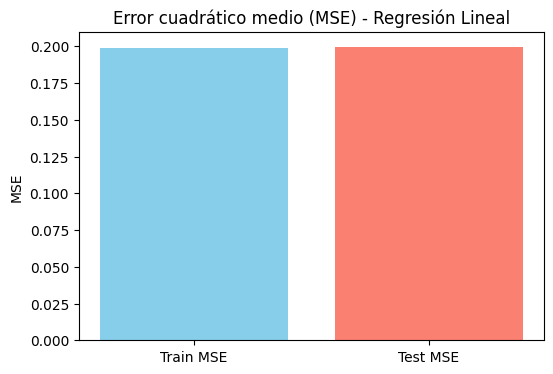

In [11]:
from sklearn.metrics import mean_squared_error

# Calcular MSE
mse_train = mean_squared_error(y_train, lr.predict(X_train))
mse_test = mean_squared_error(y_test, lr.predict(X_test))

# Graficar
plt.figure(figsize=(6,4))
plt.bar(['Train MSE', 'Test MSE'], [mse_train, mse_test], color=['skyblue','salmon'])
plt.title("Error cuadrático medio (MSE) - Regresión Lineal")
plt.ylabel("MSE")
plt.show()


# **4.2 Regresión Polinómica**

Justificación Teórica:
La regresión polinómica permite capturar relaciones no lineales entre los predictores y la variable objetivo. Al crear combinaciones de las características y elevarlas a potencias, podemos modelar interacciones más complejas. Esto es útil porque la probabilidad de inasistencia no necesariamente crece de manera lineal con variables como Age o Waiting_Days.

In [8]:
from sklearn.preprocessing import PolynomialFeatures

# Transformación polinómica de grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Modelo lineal sobre características polinómicas
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

# Predicciones
y_pred_poly = lr_poly.predict(X_test_poly)
print(f"Número de características tras transformación polinómica: {X_train_poly.shape[1]}")


Número de características tras transformación polinómica: 4094


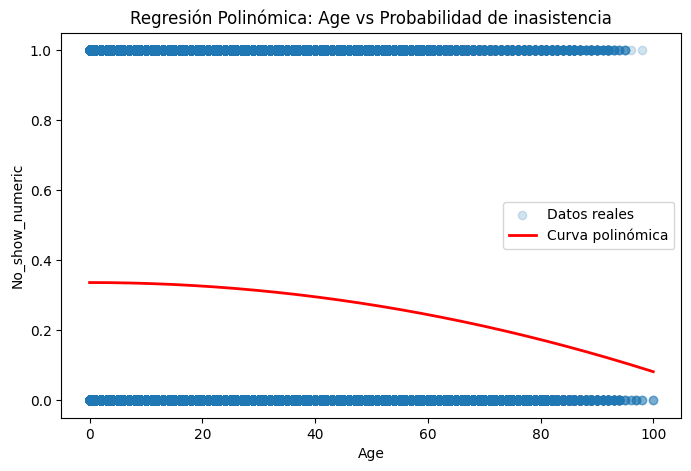

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Elegir variable
X_var = df[['Age']].values
y_var = df['No_show_numeric'].values

# Transformación polinómica grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_var)

# Modelo lineal sobre polinomial
model = LinearRegression()
model.fit(X_poly, y_var)

# Predicción para graficar
X_range = np.linspace(X_var.min(), X_var.max(), 300).reshape(-1,1)
X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly)

# Graficar
plt.figure(figsize=(8,5))
plt.scatter(X_var, y_var, alpha=0.2, label='Datos reales')
plt.plot(X_range, y_range_pred, color='red', linewidth=2, label='Curva polinómica')
plt.xlabel('Age')
plt.ylabel('No_show_numeric')
plt.title('Regresión Polinómica: Age vs Probabilidad de inasistencia')
plt.legend()
plt.show()



In [18]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


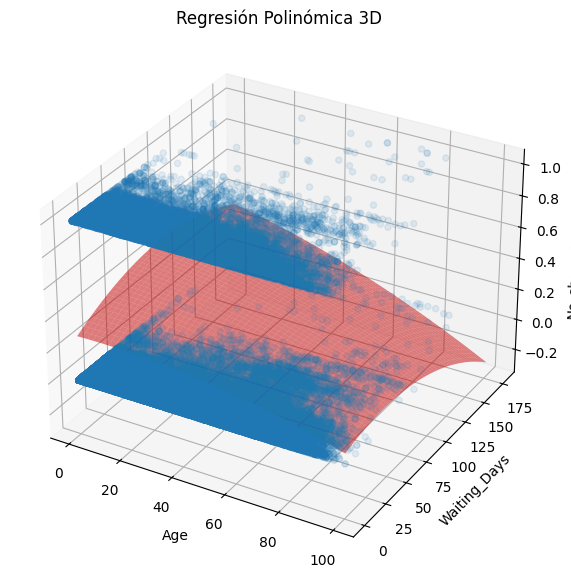

In [16]:
from mpl_toolkits.mplot3d import Axes3D

X_2var = df[['Age','Waiting_Days']].values
y_2var = df['No_show_numeric'].values

# Polinomio grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_2var)

model = LinearRegression()
model.fit(X_poly, y_2var)

# Crear malla para graficar superficie
age_range = np.linspace(df['Age'].min(), df['Age'].max(), 50)
wait_range = np.linspace(df['Waiting_Days'].min(), df['Waiting_Days'].max(), 50)
age_grid, wait_grid = np.meshgrid(age_range, wait_range)
X_grid = np.c_[age_grid.ravel(), wait_grid.ravel()]
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly).reshape(age_grid.shape)

# Graficar superficie
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Age'], df['Waiting_Days'], df['No_show_numeric'], alpha=0.1, label='Datos reales')
ax.plot_surface(age_grid, wait_grid, y_grid_pred, color='red', alpha=0.5)
ax.set_xlabel('Age')
ax.set_ylabel('Waiting_Days')
ax.set_zlabel('No_show_numeric')
ax.set_title('Regresión Polinómica 3D')
plt.show()


# **4.3 Ecuación Normal**

Justificación Teórica:
La ecuación normal calcula los parámetros óptimos de la regresión lineal directamente, sin necesidad de iteraciones, usando la fórmula:

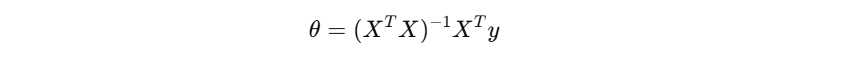

Es eficiente para conjuntos de datos de tamaño moderado y garantiza que el error cuadrático medio se minimice exactamente. Esto nos permite comparar la precisión de la solución analítica frente a la obtenida mediante gradiente descendente o regresión polinómica.

In [10]:
import numpy as np

# Añadir columna de 1s para el intercepto
X_train_poly_b = np.c_[np.ones((X_train_poly.shape[0],1)), X_train_poly]
X_test_poly_b = np.c_[np.ones((X_test_poly.shape[0],1)), X_test_poly]

# Calcular theta usando pseudo-inversa
theta = np.linalg.pinv(X_train_poly_b) @ y_train

# Predicciones
y_pred_normal = X_test_poly_b @ theta

print(f"Primeros 5 valores de theta: {theta[:5].ravel()}")


Primeros 5 valores de theta: [ 0.350678   -0.00363704 -0.03230389  0.01997708 -0.0259221 ]


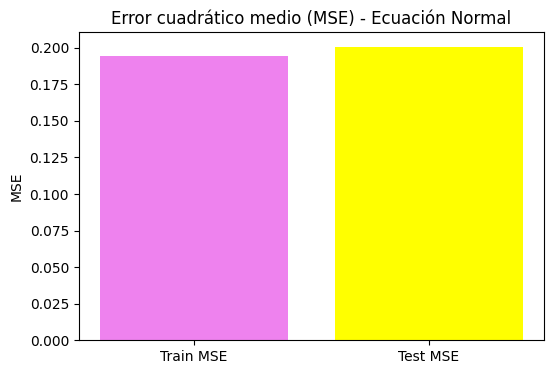

In [13]:
mse_train_normal = mean_squared_error(y_train, X_train_poly_b @ theta)
mse_test_normal = mean_squared_error(y_test, y_pred_normal)

plt.figure(figsize=(6,4))
plt.bar(['Train MSE', 'Test MSE'], [mse_train_normal, mse_test_normal], color=['violet','yellow'])
plt.title("Error cuadrático medio (MSE) - Ecuación Normal")
plt.ylabel("MSE")
plt.show()


4.4 Comparación de Modelos

Justificación Teórica:
Para evaluar la efectividad de cada modelo se utiliza el error cuadrático medio (MSE), que mide la diferencia promedio al cuadrado entre los valores predichos y los reales. Un MSE menor indica mejor ajuste.

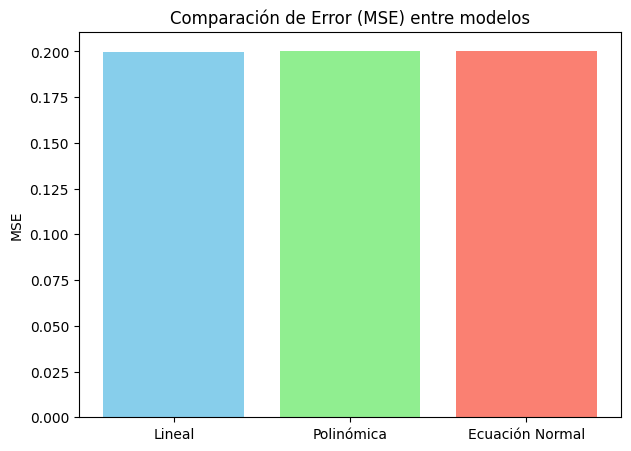

In [22]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

mse_linear = mean_squared_error(y_test, y_pred_linear)
mse_poly = mean_squared_error(y_test, y_pred_poly)
mse_normal = mean_squared_error(y_test, y_pred_normal)

plt.figure(figsize=(7,5))
plt.bar(['Lineal','Polinómica','Ecuación Normal'],
        [mse_linear, mse_poly, mse_normal],
        color=['skyblue','lightgreen','salmon'])
plt.ylabel('MSE')
plt.title('Comparación de Error (MSE) entre modelos')
plt.show()


4.5 Predicciones de 100 ejemplos

Justificación Teórica:
Para mostrar la efectividad de los modelos, se realizan predicciones sobre 100 ejemplos aleatorios del conjunto de prueba y se comparan con los valores reales.

In [24]:
sample_idx = np.random.choice(X_test.shape[0], 100, replace=False)
X_sample = X_test.iloc[sample_idx]   # <- usar .iloc
y_sample = y_test.iloc[sample_idx]

# Predicciones
y_sample_linear = lr.predict(X_sample)
y_sample_poly = lr_poly.predict(X_test_poly[sample_idx])
y_sample_normal = y_pred_normal[sample_idx]

# Crear DataFrame de predicciones
df_pred = pd.DataFrame({
    'Real': y_sample.values,
    'Lineal': y_sample_linear,
    'Polinómica': y_sample_poly,
    'Ecuación Normal': y_sample_normal
})

df_pred.head(10)


,Real,Lineal,Polinómica,Ecuación Normal
0,0,0.280619,0.308076,0.308076
1,0,0.324838,0.359139,0.359139
2,0,0.270169,0.204287,0.204287
3,1,0.415250,0.466862,0.466862
4,0,0.292796,0.260625,0.260625
5,1,0.364871,0.389326,0.389326
6,0,0.324745,0.465509,0.465509
7,0,0.269428,0.268156,0.268156
8,0,0.371707,0.277849,0.277849
9,0,0.298099,0.306542,0.306542
